# agentv19_a2a_protocol_style — corrected notebook

Start the server first:

```bash
python -m agentv19_a2a_protocol_style.a2a_agent_server
```


In [8]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

A2A_SERVER_URL = os.getenv("A2A_SERVER_URL", "http://127.0.0.1:8201")
print("A2A server URL:", A2A_SERVER_URL)
print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))


A2A server URL: http://127.0.0.1:8201
OpenAI API key present: True


In [9]:
import asyncio
import httpx

async def get_json(path: str):
    async with httpx.AsyncClient(timeout=30.0) as client:
        response = await client.get(f"{A2A_SERVER_URL}{path}")
        response.raise_for_status()
        return response.json()

async def post_json(path: str, payload: dict | None = None):
    async with httpx.AsyncClient(timeout=30.0) as client:
        response = await client.post(f"{A2A_SERVER_URL}{path}", json=payload or {})
        response.raise_for_status()
        return response.json()


## Test discovery APIs


In [10]:
health = await get_json("/health")
agent_card = await get_json("/.well-known/agent.json")
agent_card_alias = await get_json("/.well-known/agent-card.json")
model_card = await get_json("/model-card")
capabilities = await get_json("/capabilities")
skills = await get_json("/skills")

print("Health:", health)
print("Agent name:", agent_card["name"])
print("Capabilities:", capabilities)
print("Skills:", [skill["id"] for skill in skills["skills"]])


Health: {'status': 'ok', 'agent': 'epp_incident_analysis_agent'}
Agent name: EPP Incident Analysis Agent
Capabilities: {'streaming': False, 'pushNotifications': False, 'stateTransitionHistory': True, 'artifacts': True, 'cancellation': True}
Skills: ['epp_incident_analysis', 'epp_release_risk_summary']


## Test task lifecycle APIs


In [14]:
created_task = await post_json(
    "/tasks",
    {
        "input": "Investigate CHECK-DOMAIN timeout spike after R13",
        "skill_id": "epp_incident_analysis",
        "context_id": "ctx_notebook_demo",
        "metadata": {"source": "notebook"},
    },
)

task_id = created_task["task_id"]
print("Task ID:", task_id)
print("Initial state:", created_task["status"]["state"])

task_list = await get_json("/tasks")
task_detail = await get_json(f"/tasks/{task_id}")
status = await get_json(f"/tasks/{task_id}/status")

print("Task count:", len(task_list["tasks"]))
print("Task state:", task_detail["status"]["state"])
print("Status endpoint:", status)


Task ID: task_e922c452b4c4
Initial state: submitted
Task count: 2
Task state: working
Status endpoint: {'state': 'working', 'message': 'Agent is analyzing the incident.', 'updated_at': 1782592366.1588564}


## Poll task and fetch artifacts


In [15]:
terminal_states = {"completed", "failed", "canceled", "rejected"}

while True:
    task_detail = await get_json(f"/tasks/{task_id}")
    state = task_detail["status"]["state"]
    print("State:", state)
    if state in terminal_states:
        break
    await asyncio.sleep(0.3)

artifacts = await get_json(f"/tasks/{task_id}/artifacts")
print("Artifacts:", artifacts)


State: completed
Artifacts: {'task_id': 'task_e922c452b4c4', 'artifacts': [{'artifact_id': 'artifact_acb7929197fa', 'name': 'incident_analysis', 'parts': [{'type': 'text', 'text': 'Likely cause: CHECK-DOMAIN timeout spike is consistent with upstream registry connectivity degradation or connection pool saturation after R13. Evidence: elevated p95 response_time around 240 ms, increased CONNECTION_TIMEOUT volume, and concentration around peak traffic/client_b. Recommended next action: inspect registry endpoint health, DNS resolver latency, connection pool saturation, and compare pre/post-release failure volume by command and client.', 'data': None}, {'type': 'json', 'text': None, 'data': {'likely_cause': 'registry connectivity or connection pool saturation', 'primary_command': 'CHECK-DOMAIN', 'primary_failure_reason': 'CONNECTION_TIMEOUT', 'recommended_actions': ['inspect registry endpoint health', 'check DNS resolver latency', 'check connection pool saturation', 'compare pre/post-release

## Test cancellation and rejection


In [16]:
cancel_task = await post_json("/tasks", {"input": "Long investigation to cancel", "skill_id": "epp_incident_analysis"})
cancel_task_id = cancel_task["task_id"]
canceled = await post_json(f"/tasks/{cancel_task_id}/cancel")
print("Canceled state:", canceled["status"]["state"])

rejected = await post_json("/tasks", {"input": "Unsupported skill test", "skill_id": "unsupported_skill"})
print("Rejected state:", rejected["status"]["state"])
print("Rejected message:", rejected["status"]["message"])


Canceled state: canceled
Rejected state: rejected
Rejected message: Unsupported skill_id: unsupported_skill


## Define LangGraph host state


In [17]:
from typing import NotRequired, TypedDict

class AgentState(TypedDict):
    input: str
    agent_card: NotRequired[dict]
    capabilities: NotRequired[dict]
    task_id: NotRequired[str]
    task: NotRequired[dict]
    artifacts: NotRequired[dict]
    final_answer: NotRequired[str]


## Define LangGraph host nodes


In [18]:
from langchain_openai import ChatOpenAI

async def discover_agent_node(state: AgentState) -> AgentState:
    return {
        "agent_card": await get_json("/.well-known/agent.json"),
        "capabilities": await get_json("/capabilities"),
    }

async def submit_task_node(state: AgentState) -> AgentState:
    task = await post_json(
        "/tasks",
        {
            "input": state["input"],
            "skill_id": "epp_incident_analysis",
            "context_id": "ctx_langgraph_host",
            "metadata": {"caller": "notebook_host"},
        },
    )
    return {"task_id": task["task_id"], "task": task}

async def poll_task_node(state: AgentState) -> AgentState:
    while True:
        task = await get_json(f"/tasks/{state['task_id']}")
        if task["status"]["state"] in {"completed", "failed", "canceled", "rejected"}:
            return {"task": task}
        await asyncio.sleep(0.3)

async def fetch_artifacts_node(state: AgentState) -> AgentState:
    artifacts = await get_json(f"/tasks/{state['task_id']}/artifacts")
    return {"artifacts": artifacts}

async def synthesize_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    prompt = f'''
User request:
{state["input"]}

Remote agent:
{state["agent_card"]["name"]}

Capabilities:
{state["capabilities"]}

Task:
{state["task"]}

Artifacts:
{state["artifacts"]}

Write a concise final answer based on the remote A2A agent result.
'''
    response = await llm.ainvoke(prompt)
    return {"final_answer": response.content}


## Build and create graph


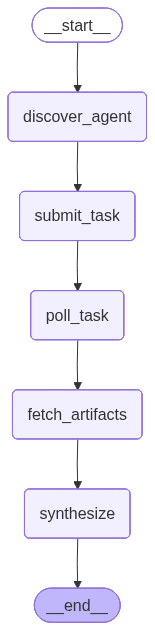

In [19]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("discover_agent", discover_agent_node)
    graph_builder.add_node("submit_task", submit_task_node)
    graph_builder.add_node("poll_task", poll_task_node)
    graph_builder.add_node("fetch_artifacts", fetch_artifacts_node)
    graph_builder.add_node("synthesize", synthesize_node)

    graph_builder.add_edge(START, "discover_agent")
    graph_builder.add_edge("discover_agent", "submit_task")
    graph_builder.add_edge("submit_task", "poll_task")
    graph_builder.add_edge("poll_task", "fetch_artifacts")
    graph_builder.add_edge("fetch_artifacts", "synthesize")
    graph_builder.add_edge("synthesize", END)

    return graph_builder.compile()

graph = build_graph()
graph


## Visualize graph


In [20]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	discover_agent(discover_agent)
	submit_task(submit_task)
	poll_task(poll_task)
	fetch_artifacts(fetch_artifacts)
	synthesize(synthesize)
	__end__([<p>__end__</p>]):::last
	__start__ --> discover_agent;
	discover_agent --> submit_task;
	fetch_artifacts --> synthesize;
	poll_task --> fetch_artifacts;
	submit_task --> poll_task;
	synthesize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## Run graph


In [21]:
result = await graph.ainvoke({
    "input": "Investigate CHECK-DOMAIN timeout spike after R13."
})

print("Remote agent:", result["agent_card"]["name"])
print("Task:", result["task_id"])
print("State:", result["task"]["status"]["state"])
print()
print(result["final_answer"])


Remote agent: EPP Incident Analysis Agent
Task: task_8e97f073a366
State: completed

The CHECK-DOMAIN timeout spike after R13 is likely due to upstream registry connectivity degradation or connection pool saturation. Evidence includes an elevated p95 response time of around 240 ms and an increased volume of CONNECTION_TIMEOUTs, particularly during peak traffic for client_b. 

Recommended next actions are to:
1. Inspect registry endpoint health.
2. Check DNS resolver latency.
3. Assess connection pool saturation.
4. Compare pre/post-release failure volumes by command and client.


## Stream graph updates


In [22]:
async for chunk in graph.astream(
    {"input": "Investigate CHECK-DOMAIN timeout spike after R13."},
    stream_mode="updates",
):
    print("\n--- update ---")
    print(chunk)



--- update ---
{'discover_agent': {'agent_card': {'name': 'EPP Incident Analysis Agent', 'description': 'Analyzes EPP SLA incidents using metrics and runbook-style reasoning.', 'version': '1.0.0', 'url': 'http://127.0.0.1:8201', 'provider': {'organization': 'AgenticAI Learn', 'url': 'http://localhost'}, 'capabilities': {'streaming': False, 'pushNotifications': False, 'stateTransitionHistory': True, 'artifacts': True, 'cancellation': True}, 'defaultInputModes': ['text/plain', 'application/json'], 'defaultOutputModes': ['text/plain', 'application/json'], 'skills': [{'id': 'epp_incident_analysis', 'name': 'EPP incident analysis', 'description': 'Investigates EPP SLA failures, latency, timeout spikes, and release impact.', 'inputModes': ['text/plain', 'application/json'], 'outputModes': ['text/plain', 'application/json'], 'examples': ['Investigate CHECK-DOMAIN timeout spike after R13']}, {'id': 'epp_release_risk_summary', 'name': 'EPP release risk summary', 'description': 'Summarizes like